Shape of dataset: (253680, 23)

Sample data:
    id  HighBP  HighChol  CholCheck  BMI  Smoker  Stroke  Diabetes  \
0   0       1         1          1   40       1       0         0   
1   1       0         0          0   25       1       0         0   
2   2       1         1          1   28       0       0         0   
3   3       1         0          1   27       0       0         0   
4   4       1         1          1   24       0       0         0   

   PhysActivity  Fruits  ...  NoDocbcCost  GenHlth  MentHlth  PhysHlth  \
0             0       0  ...            0        5        18        15   
1             1       0  ...            1        3         0         0   
2             0       1  ...            1        5        30        30   
3             1       1  ...            0        2         0         0   
4             1       1  ...            0        2         3         0   

   DiffWalk  Sex  Age  Education  Income  HeartDiseaseorAttack  
0         1    0    9        

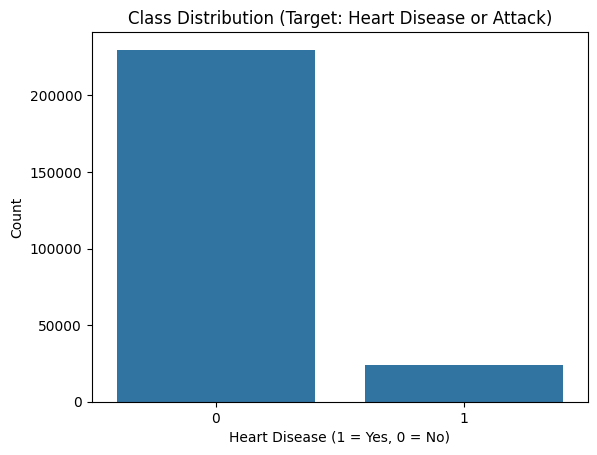

 'id' column dropped.

Descriptive statistics:
               HighBP       HighChol      CholCheck            BMI  \
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        0.429001       0.424121       0.962670      28.382364   
std         0.494934       0.494210       0.189571       6.608694   
min         0.000000       0.000000       0.000000      12.000000   
25%         0.000000       0.000000       1.000000      24.000000   
50%         0.000000       0.000000       1.000000      27.000000   
75%         1.000000       1.000000       1.000000      31.000000   
max         1.000000       1.000000       1.000000      98.000000   

              Smoker         Stroke       Diabetes   PhysActivity  \
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        0.443169       0.040571       0.296921       0.756544   
std         0.496761       0.197294       0.698160       0.429169   
min         0.000000       0.000000       0.000000    

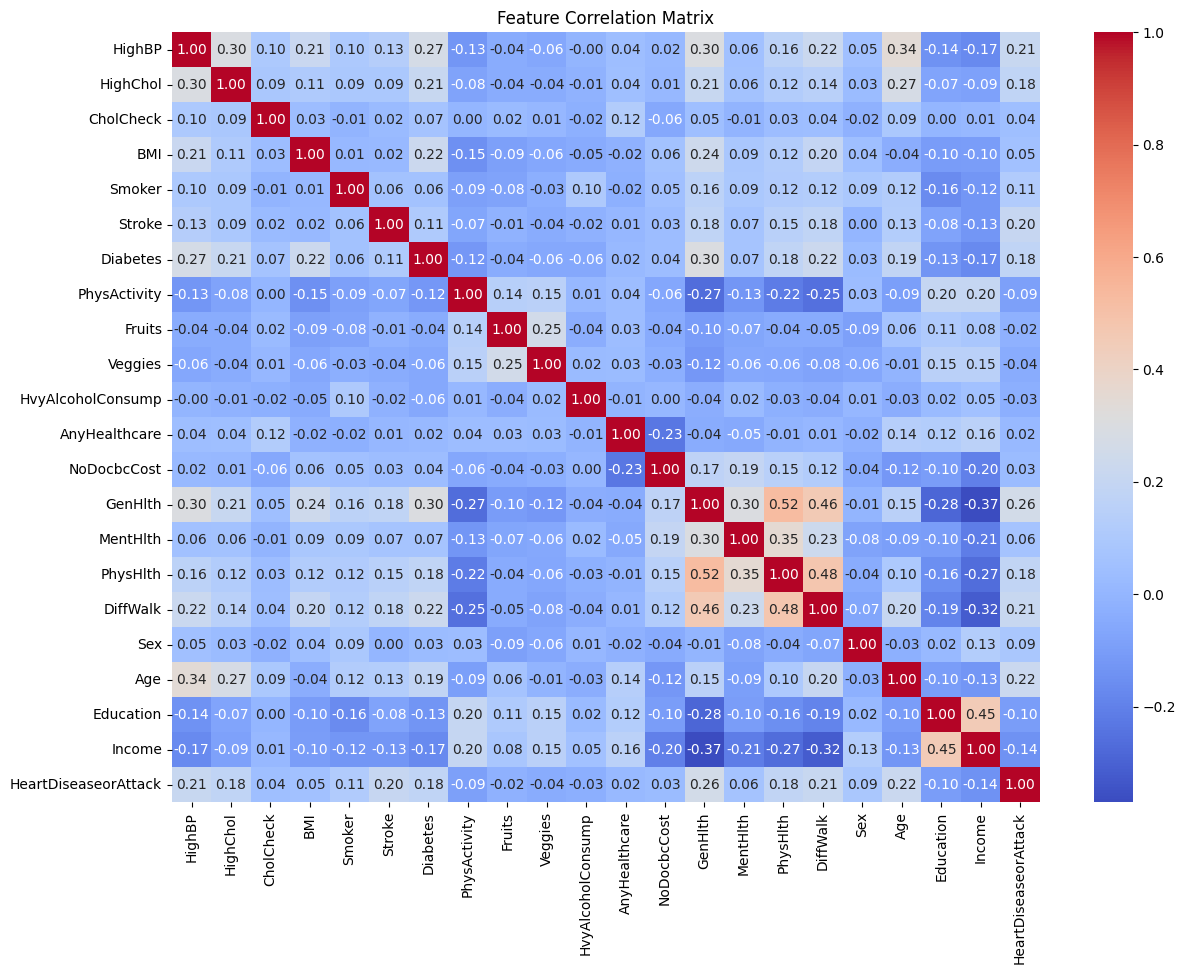

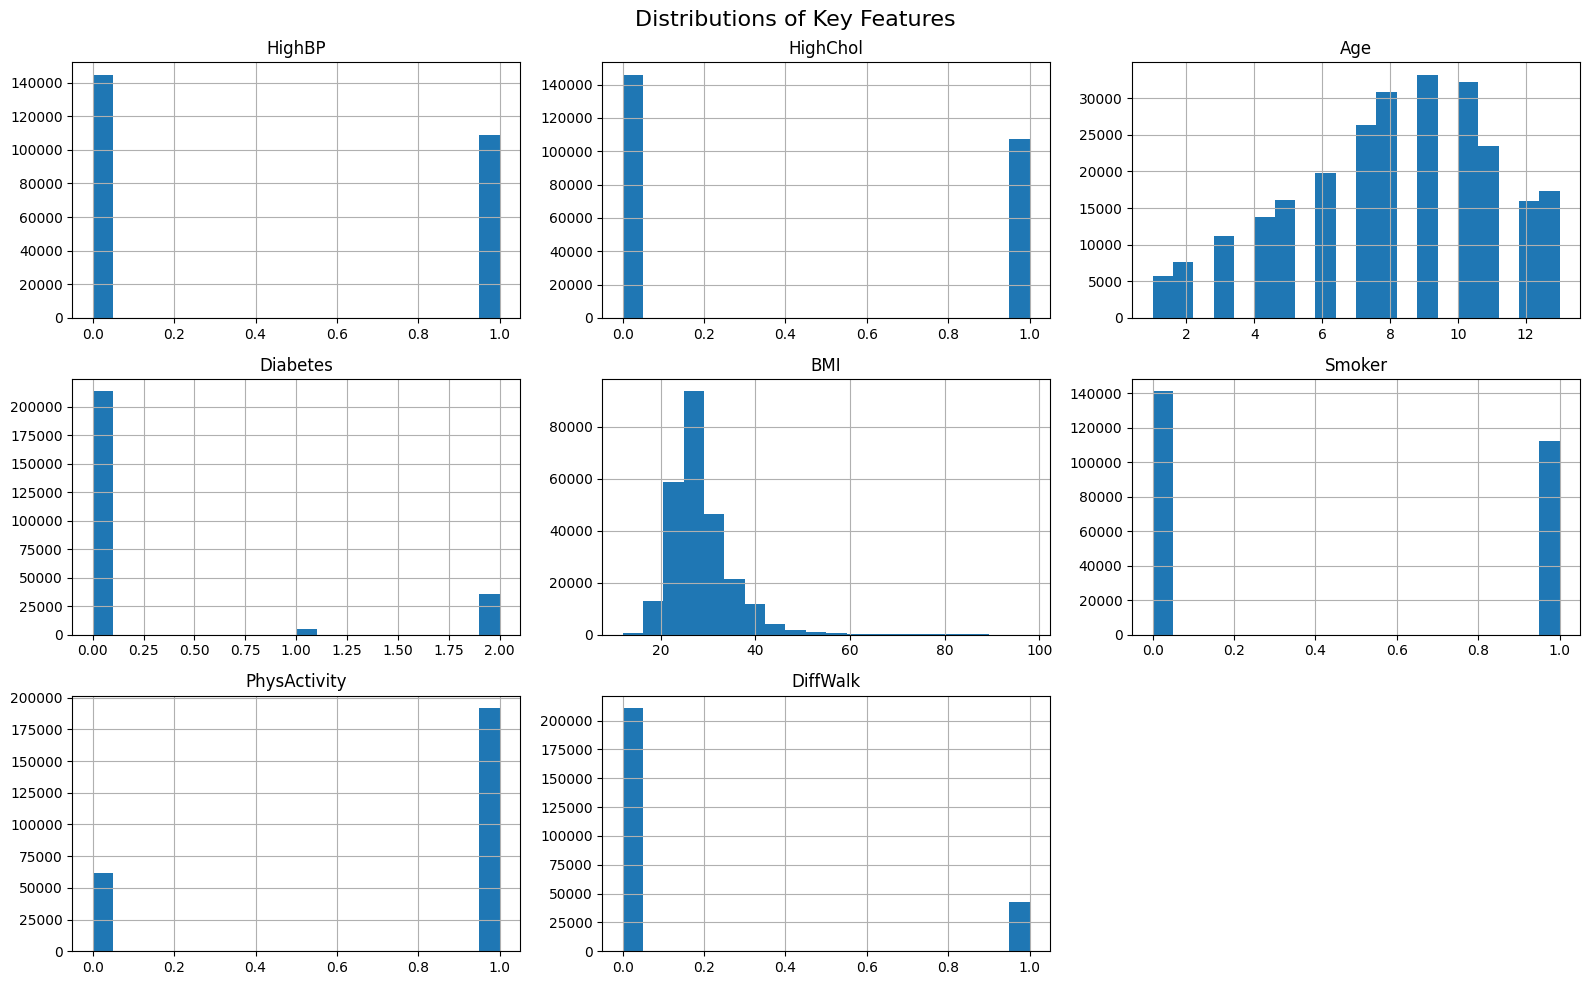


Mean values grouped by target class:
 HeartDiseaseorAttack          0          1
BMI                   28.269624  29.466622
Age                    7.813858  10.131210
PhysHlth               3.731299   9.154439
Income                 6.148050   5.148161
Education              5.082093   4.745951
MentHlth               3.030306   4.670322
GenHlth                2.422369   3.367555
CholCheck              0.959967   0.988658
AnyHealthcare          0.949749   0.963588
Veggies                0.816360   0.763906


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data
df = pd.read_csv("7_data.csv")

# Quick Summary
print("Shape of dataset:", df.shape)
print("\nSample data:\n", df.head())
print("\nData types:\n", df.dtypes)

# Check for Missing Values
missing = df.isnull().sum()
print("\nMissing values in each column:\n", missing[missing > 0] if missing.any() else "✅ No missing values found!")

# Target Variable Check
target = 'HeartDiseaseorAttack'
print("\nClass distribution:\n", df[target].value_counts(normalize=True).rename_axis('class').reset_index(name='proportion'))

# Visualizing Class Balance
sns.countplot(x=target, data=df)
plt.title("Class Distribution (Target: Heart Disease or Attack)")
plt.xlabel("Heart Disease (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

# Drop ID Column if present
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    print(" 'id' column dropped.")

# Summary Statistics
print("\nDescriptive statistics:\n", df.describe())

# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

# Distribution of Top Features
top_features = ['HighBP', 'HighChol', 'Age', 'Diabetes', 'BMI', 'Smoker', 'PhysActivity', 'DiffWalk']
df[top_features].hist(figsize=(16, 10), bins=20)
plt.suptitle("Distributions of Key Features", fontsize=16)
plt.tight_layout()
plt.show()

# Compare Means for Target Classes
print("\nMean values grouped by target class:\n", df.groupby(target).mean().T.sort_values(by=1, ascending=False).head(10))

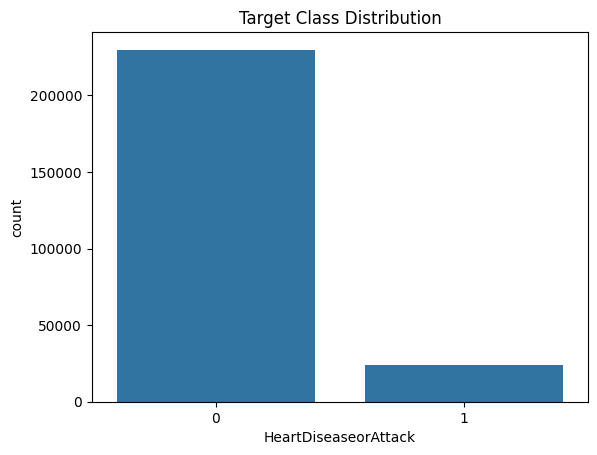

HeartDiseaseorAttack
0    90.581441
1     9.418559
Name: proportion, dtype: float64


In [6]:
sns.countplot(data=df, x="HeartDiseaseorAttack")
plt.title("Target Class Distribution")
plt.show()

print(df["HeartDiseaseorAttack"].value_counts(normalize=True) * 100)

In [7]:
df.isnull().sum().sort_values(ascending=False)

HighBP                  0
HighChol                0
Income                  0
Education               0
Age                     0
Sex                     0
DiffWalk                0
PhysHlth                0
MentHlth                0
GenHlth                 0
NoDocbcCost             0
AnyHealthcare           0
HvyAlcoholConsump       0
Veggies                 0
Fruits                  0
PhysActivity            0
Diabetes                0
Stroke                  0
Smoker                  0
BMI                     0
CholCheck               0
HeartDiseaseorAttack    0
dtype: int64

In [8]:
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,HeartDiseaseorAttack
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.296921,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.094186
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.698160,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.292087
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


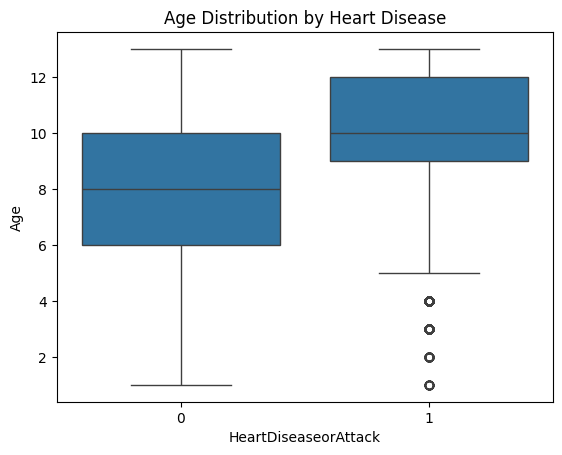

In [9]:
sns.boxplot(data=df, x="HeartDiseaseorAttack", y="Age")
plt.title("Age Distribution by Heart Disease")
plt.show()

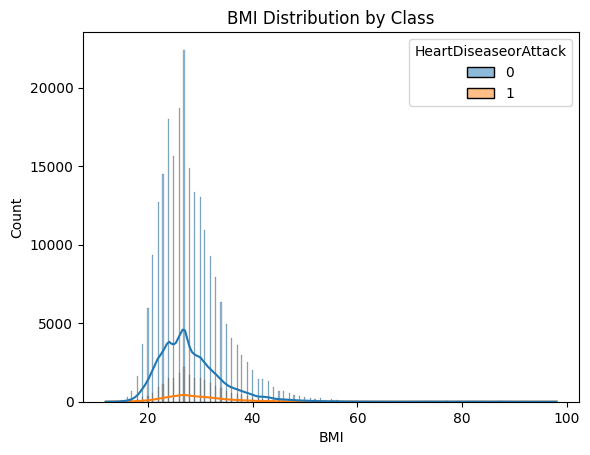

In [10]:
sns.histplot(data=df, x="BMI", hue="HeartDiseaseorAttack", kde=True)
plt.title("BMI Distribution by Class")
plt.show()

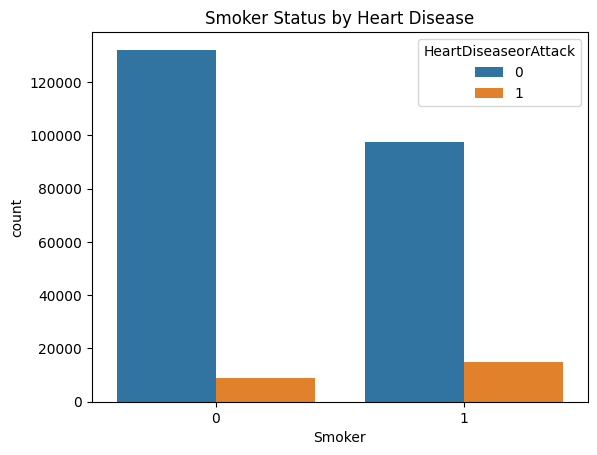

In [11]:
sns.countplot(data=df, x="Smoker", hue="HeartDiseaseorAttack")
plt.title("Smoker Status by Heart Disease")
plt.show()

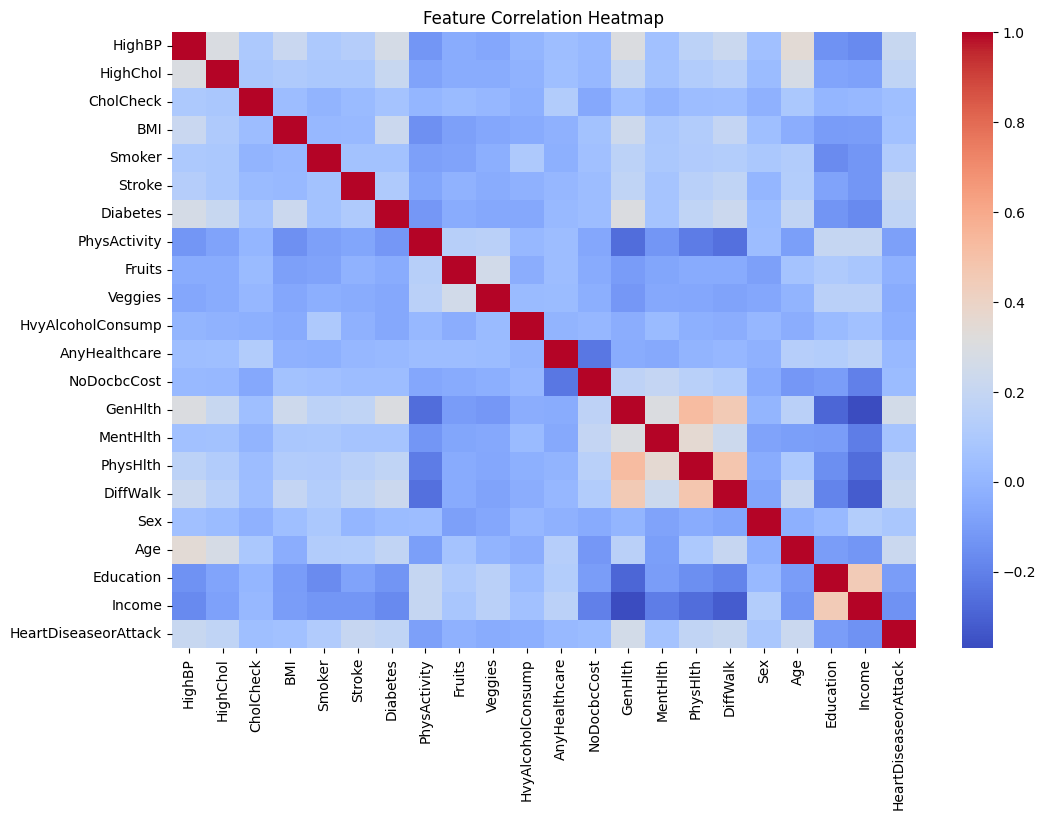

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   id                    253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   Diabetes              253680 non-null  int64
 8   PhysActivity          253680 non-null  int64
 9   Fruits                253680 non-null  int64
 10  Veggies               253680 non-null  int64
 11  HvyAlcoholConsump     253680 non-null  int64
 12  AnyHealthcare         253680 non-null  int64
 13  NoDocbcCost           253680 non-null  int64
 14  GenHlth               253680 non-null  int64
 15  MentHlth              253680 non-n

<Figure size 600x400 with 0 Axes>

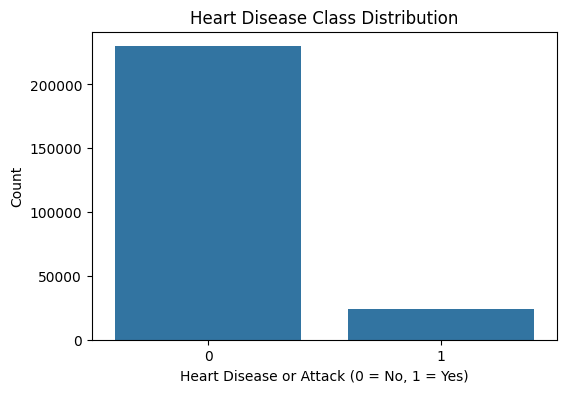

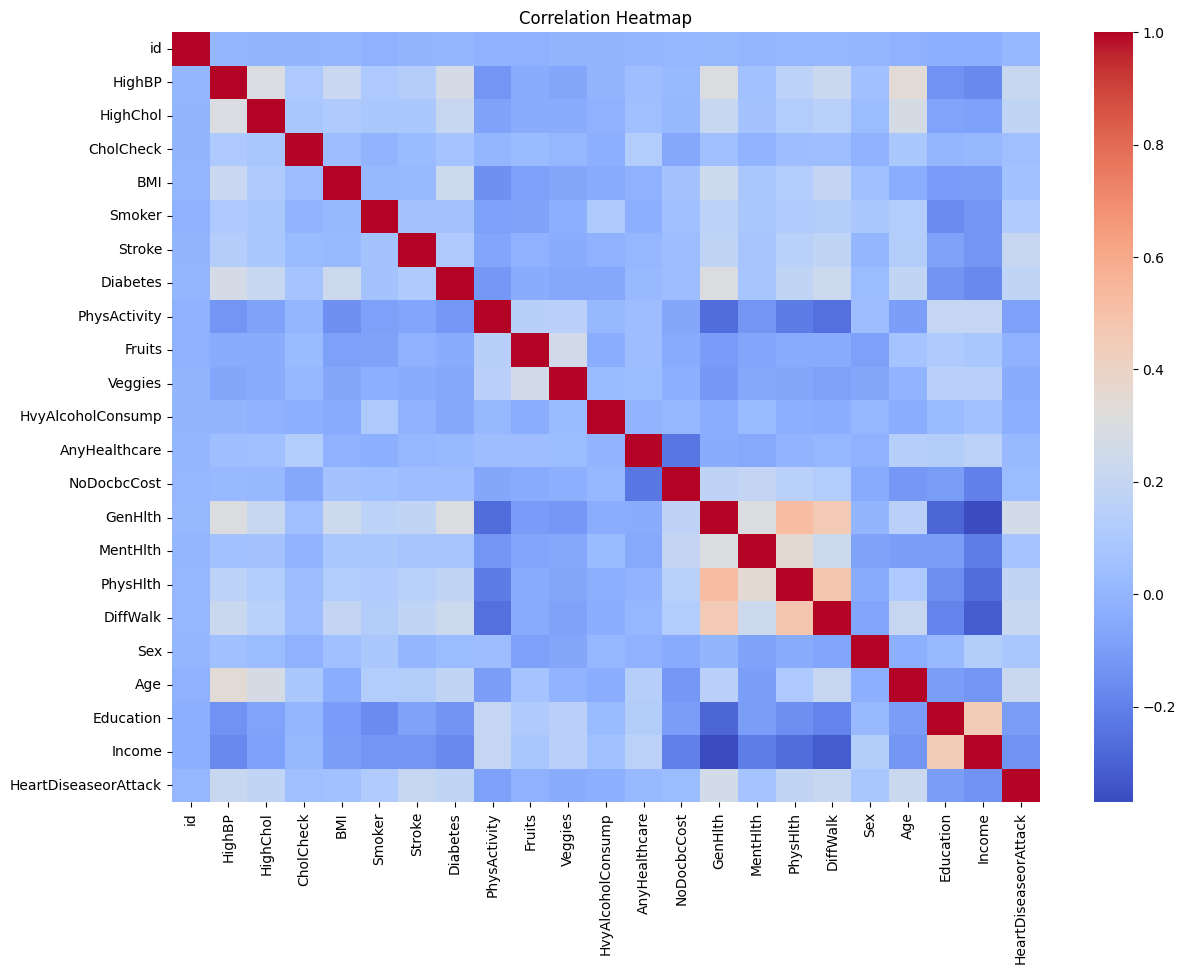

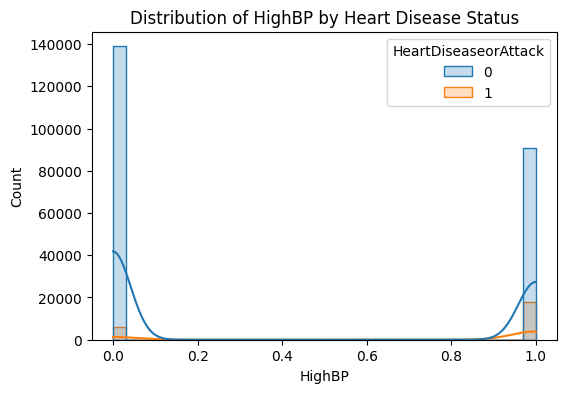

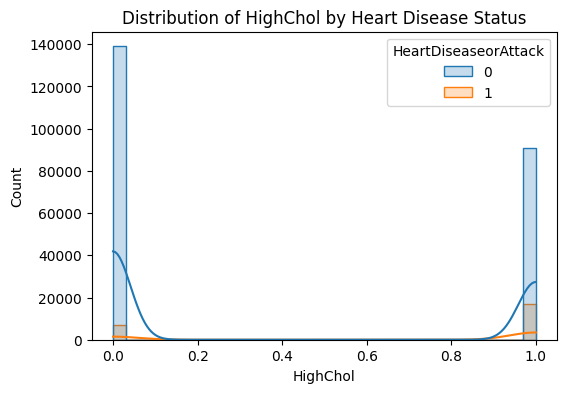

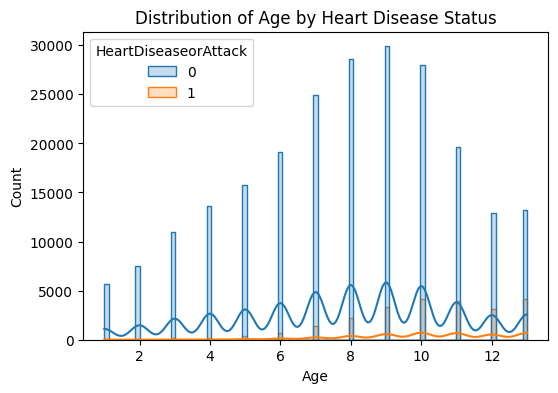

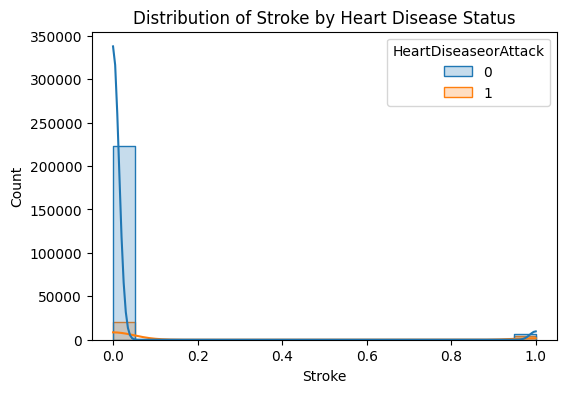

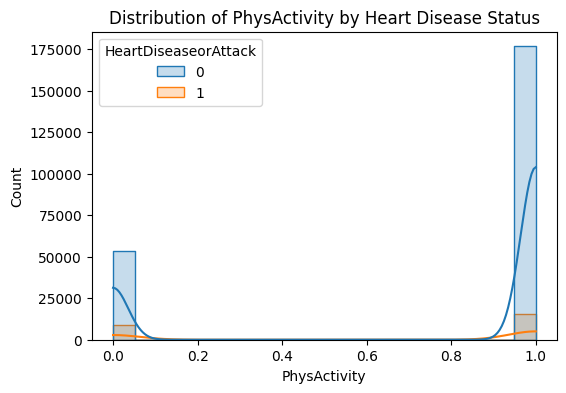

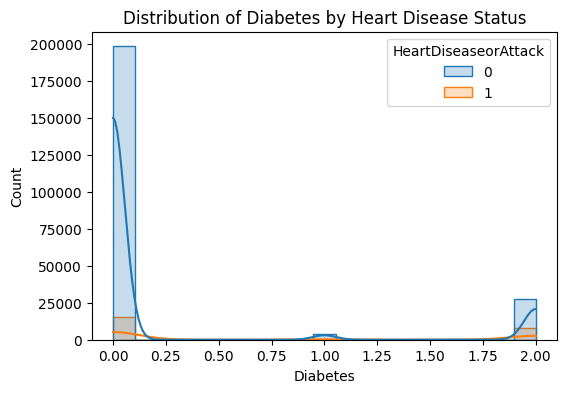

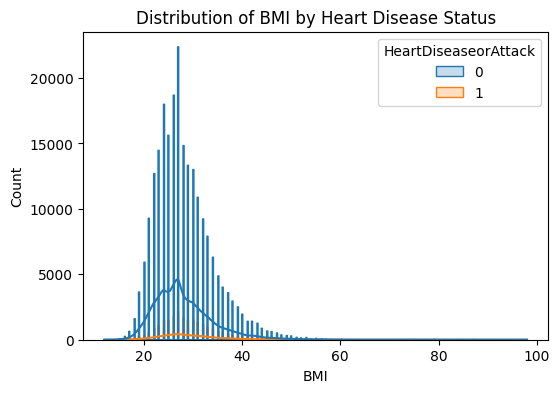

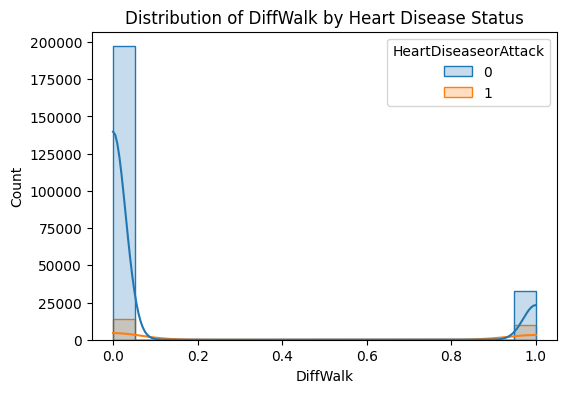

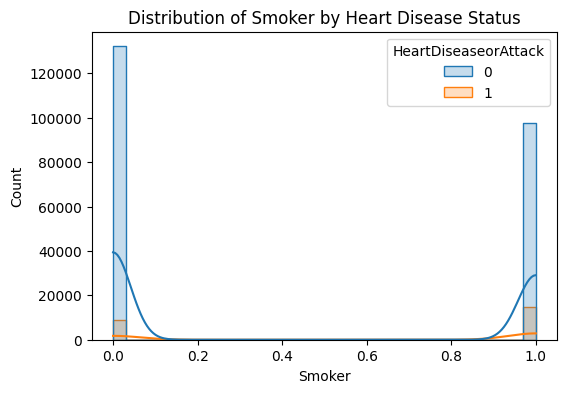

ValueError: Could not interpret value `MentlHlth` for `x`. An entry with this name does not appear in `data`.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("7_data.csv")

# 1. Basic Overview
print(df.info())
print(df.describe())
print(df['HeartDiseaseorAttack'].value_counts())

# 2. Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='HeartDiseaseorAttack')
plt.title('Heart Disease Class Distribution')
plt.xlabel('Heart Disease or Attack (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

# 4. Distribution of Top Predictors
top_features = ['HighBP', 'HighChol', 'Age', 'Stroke', 'PhysActivity', 'Diabetes', 'BMI', 'DiffWalk', 'Smoker', 'MentlHlth']
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='HeartDiseaseorAttack', kde=True, element='step')
    plt.title(f'Distribution of {col} by Heart Disease Status')
    plt.show()

# 5. Bar Plots for Categorical Variables
cat_features = ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'PhysActivity', 'Stroke', 'DiffWalk']
for col in cat_features:
    plt.figure(figsize=(6,4))
    sns.barplot(x=col, y='HeartDiseaseorAttack', data=df)
    plt.title(f'Heart Disease Rate by {col}')
    plt.ylabel('Proportion with Heart Disease')
    plt.show()

# 6. Boxplots for Numerical Features
num_features = ['Age', 'BMI', 'MentHlth', 'PhysHlth']
for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='HeartDiseaseorAttack', y=col)
    plt.title(f'{col} vs Heart Disease')
    plt.xlabel('Heart Disease or Attack (0 = No, 1 = Yes)')
    plt.ylabel(col)
    plt.show()

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Load your dataset
# df = pd.read_csv('your_data.csv')

# 2. Drop the ID column
df = df.drop(columns=['id'], errors='ignore')  # avoid crash if 'id' already dropped

# 3. Define target and features
target = 'HeartDiseaseorAttack'
X = df.drop(columns=[target])
y = df[target]

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Train a basic Random Forest model
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# 6. Predictions
y_pred = rf.predict(X_test)

# 7. Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

# 8. Detailed report
report = classification_report(y_test, y_pred, target_names=['No Heart Disease', 'Heart Disease'])

print("Random Forest Classifier Evaluation:")
print("Overall Accuracy:", round(accuracy * 100, 2), "%")
print("Precision (Class 1):", round(precision * 100, 2), "%")
print("Recall (Class 1):", round(recall * 100, 2), "%")
print("F1 Score (Class 1):", round(f1 * 100, 2), "%")
print("\n Classification Report:\n")
print(report)


Random Forest Classifier Evaluation:
Overall Accuracy: 89.89 %
Precision (Class 1): 36.14 %
Recall (Class 1): 9.52 %
F1 Score (Class 1): 15.07 %

 Classification Report:

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.98      0.95     45957
   Heart Disease       0.36      0.10      0.15      4779

        accuracy                           0.90     50736
       macro avg       0.64      0.54      0.55     50736
    weighted avg       0.86      0.90      0.87     50736



In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Load your dataset
# df = pd.read_csv('7_data.csv')

# 2. Drop the ID column
df = df.drop(columns=['id'], errors='ignore')

# 3. Define features and target
target = 'HeartDiseaseorAttack'
X = df.drop(columns=[target])
y = df[target]

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Train Random Forest with class_weight='balanced'
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# 6. Predictions
y_pred = rf.predict(X_test)

# 7. Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

# 8. Classification Report
report = classification_report(
    y_test, y_pred,
    target_names=['No Heart Disease', 'Heart Disease']
)

# 9. Print results
print("Random Forest (class_weight='balanced') Evaluation:")
print("Overall Accuracy:", round(accuracy * 100, 2), "%")
print("Precision (Class 1):", round(precision * 100, 2), "%")
print("Recall (Class 1):", round(recall * 100, 2), "%")
print("F1 Score (Class 1):", round(f1 * 100, 2), "%")
print("\nClassification Report:\n")
print(report)


Random Forest (class_weight='balanced') Evaluation:
Overall Accuracy: 89.89 %
Precision (Class 1): 36.14 %
Recall (Class 1): 9.52 %
F1 Score (Class 1): 15.07 %

Classification Report:

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.98      0.95     45957
   Heart Disease       0.36      0.10      0.15      4779

        accuracy                           0.90     50736
       macro avg       0.64      0.54      0.55     50736
    weighted avg       0.86      0.90      0.87     50736



In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# 1. Drop the ID column (if exists)
df = df.drop(columns=['id'], errors='ignore')

# 2. Define features and target
target = 'HeartDiseaseorAttack'
X = df.drop(columns=[target])
y = df[target]

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Train Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# 5. Predictions
y_pred = gb_model.predict(X_test)

# 6. Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

# 7. Classification report
report = classification_report(
    y_test, y_pred,
    target_names=['No Heart Disease', 'Heart Disease']
)

# 8. Print results
print("Gradient Boosting Classifier Evaluation:")
print("Overall Accuracy:", round(accuracy * 100, 2), "%")
print("Precision (Class 1):", round(precision * 100, 2), "%")
print("Recall (Class 1):", round(recall * 100, 2), "%")
print("F1 Score (Class 1):", round(f1 * 100, 2), "%")
print("\n Classification Report:\n")
print(report)


Gradient Boosting Classifier Evaluation:
Overall Accuracy: 90.74 %
Precision (Class 1): 54.07 %
Recall (Class 1): 11.26 %
F1 Score (Class 1): 18.64 %

 Classification Report:

                  precision    recall  f1-score   support

No Heart Disease       0.91      0.99      0.95     45957
   Heart Disease       0.54      0.11      0.19      4779

        accuracy                           0.91     50736
       macro avg       0.73      0.55      0.57     50736
    weighted avg       0.88      0.91      0.88     50736



In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Make sure ID column is dropped and data is pre-split into X_train, X_test, y_train, y_test

# Train Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Train Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

# Evaluation function
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)
    print(f"\n {name} Results")
    print("Accuracy:", round(accuracy * 100, 2), "%")
    print("Class 1 Precision:", round(precision * 100, 2), "%")
    print("Class 1 Recall:", round(recall * 100, 2), "%")
    print("Class 1 F1-Score:", round(f1 * 100, 2), "%")
    print("\n Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['No Heart Disease', 'Heart Disease']))
    return {
        "Model": name,
        "Accuracy": accuracy * 100,
        "Recall": recall * 100,
        "Precision": precision * 100,
        "F1": f1 * 100
    }

# Evaluate both models
lr_results = evaluate_model("Logistic Regression (balanced)", y_test, lr_preds)
nb_results = evaluate_model("Naive Bayes", y_test, nb_preds)


 Logistic Regression (balanced) Results
Accuracy: 75.35 %
Class 1 Precision: 24.83 %
Class 1 Recall: 79.74 %
Class 1 F1-Score: 37.87 %

 Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.97      0.75      0.85     45957
   Heart Disease       0.25      0.80      0.38      4779

        accuracy                           0.75     50736
       macro avg       0.61      0.77      0.61     50736
    weighted avg       0.90      0.75      0.80     50736


 Naive Bayes Results
Accuracy: 81.53 %
Class 1 Precision: 26.41 %
Class 1 Recall: 53.82 %
Class 1 F1-Score: 35.43 %

 Classification Report:
                  precision    recall  f1-score   support

No Heart Disease       0.95      0.84      0.89     45957
   Heart Disease       0.26      0.54      0.35      4779

        accuracy                           0.82     50736
       macro avg       0.61      0.69      0.62     50736
    weighted avg       0.88      0.82      0.84     50

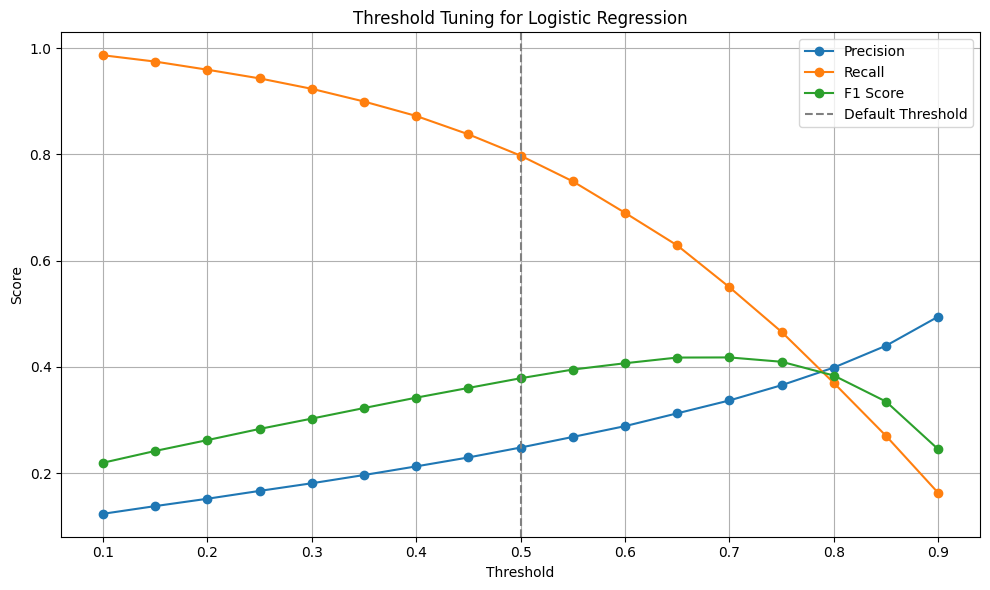

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

# Drop target and 'id' only if they exist
X = df.drop(columns=[col for col in ['HeartDiseaseorAttack', 'id'] if col in df.columns])
y = df['HeartDiseaseorAttack']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train Logistic Regression with class balancing
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train, y_train)

# Get predicted probabilities for class 1
y_probs = lr.predict_proba(X_test)[:, 1]

# Evaluate thresholds
thresholds = np.arange(0.1, 0.91, 0.05)
precision_scores = []
recall_scores = []
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    precision_scores.append(precision_score(y_test, y_pred_thresh))
    recall_scores.append(recall_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_scores, label='Precision', marker='o')
plt.plot(thresholds, recall_scores, label='Recall', marker='o')
plt.plot(thresholds, f1_scores, label='F1 Score', marker='o')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default Threshold')
plt.title('Threshold Tuning for Logistic Regression')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
from sklearn.metrics import classification_report

# Reuse the trained Logistic Regression model and predicted probabilities
# If needed: y_probs = lr.predict_proba(X_test)[:, 1]

# Apply the custom threshold
custom_threshold = 0.35
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# Show classification report
report = classification_report(y_test, y_pred_custom, target_names=["No Heart Disease", "Heart Disease"])
print(f"Classification Report (Threshold = {custom_threshold}):\n")
print(report)

Classification Report (Threshold = 0.35):

                  precision    recall  f1-score   support

No Heart Disease       0.98      0.62      0.76     45957
   Heart Disease       0.20      0.90      0.32      4779

        accuracy                           0.64     50736
       macro avg       0.59      0.76      0.54     50736
    weighted avg       0.91      0.64      0.72     50736



In [36]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_test, y_pred_custom)
f1_macro = f1_score(y_test, y_pred_custom, average='macro')
f1_weighted = f1_score(y_test, y_pred_custom, average='weighted')

print(f" Accuracy: {accuracy * 100:.2f}%")
print(f" Macro Avg F1 Score: {f1_macro:.4f}")
print(f" Weighted Avg F1 Score: {f1_weighted:.4f}")

 Accuracy: 64.42%
 Macro Avg F1 Score: 0.5407
 Weighted Avg F1 Score: 0.7177


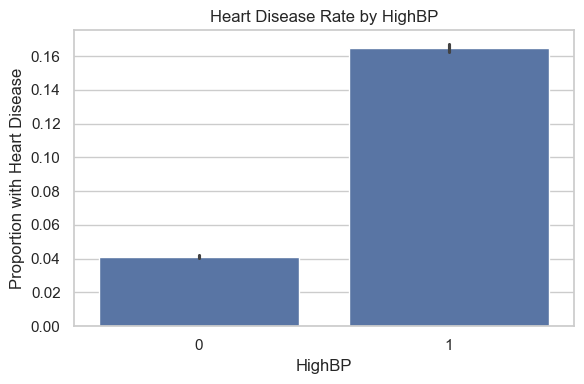

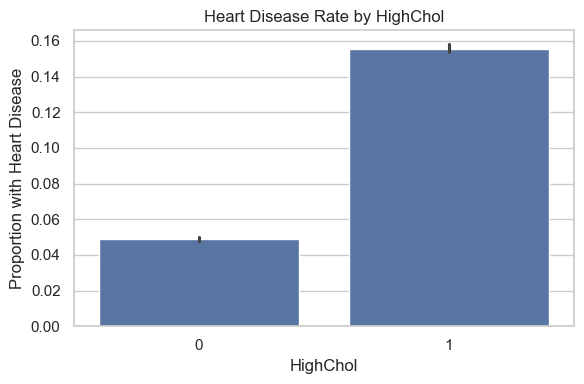

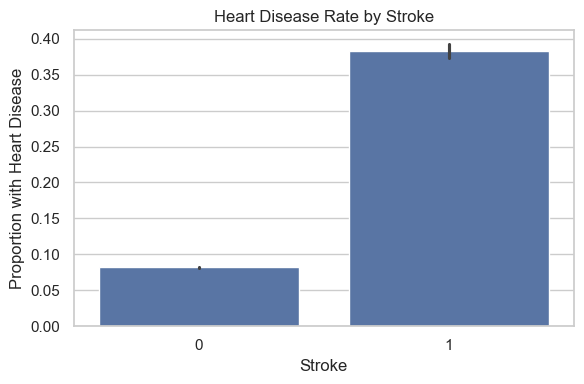

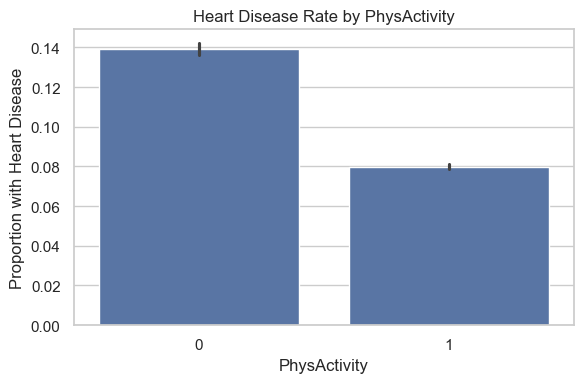

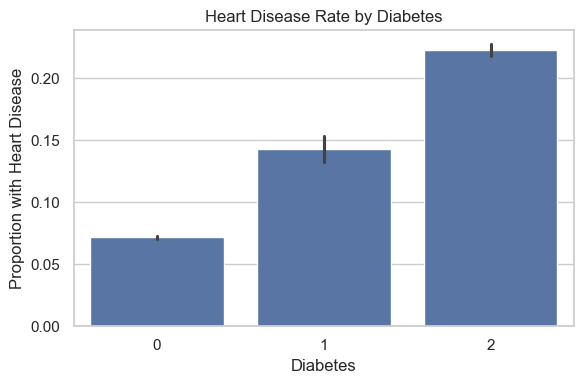

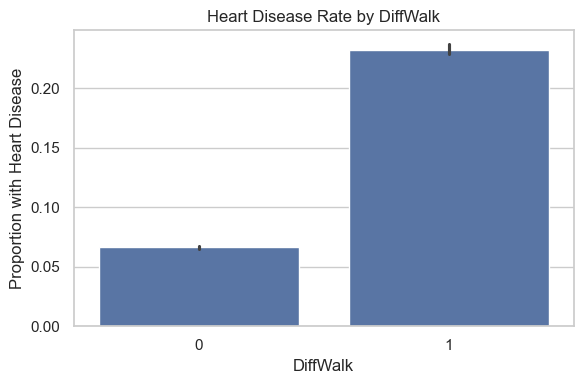

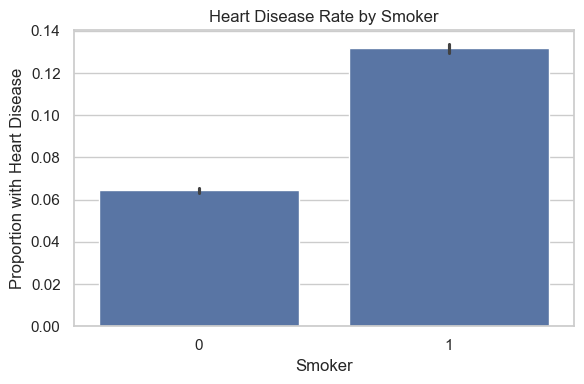

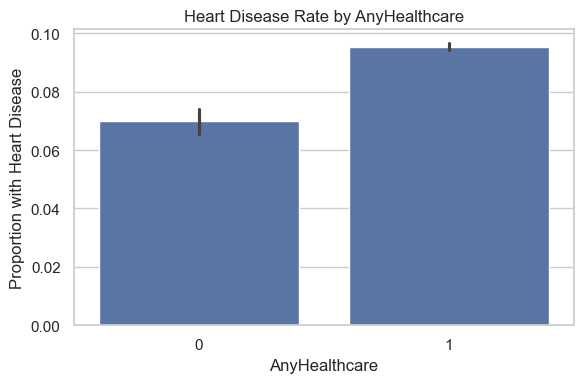

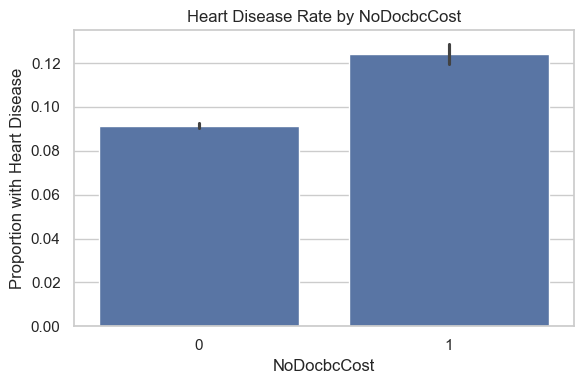

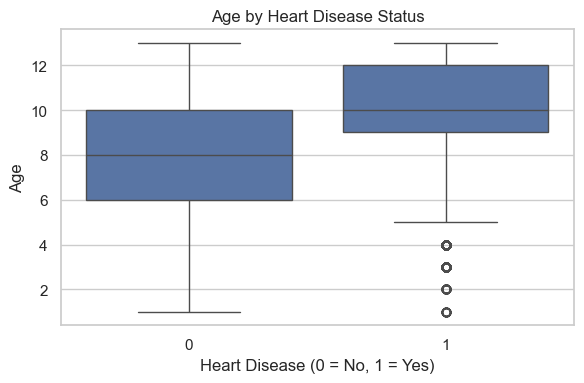

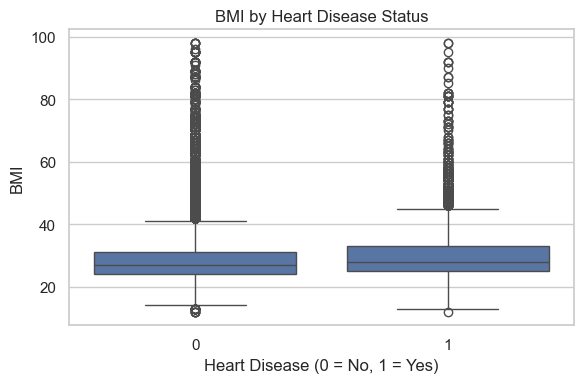

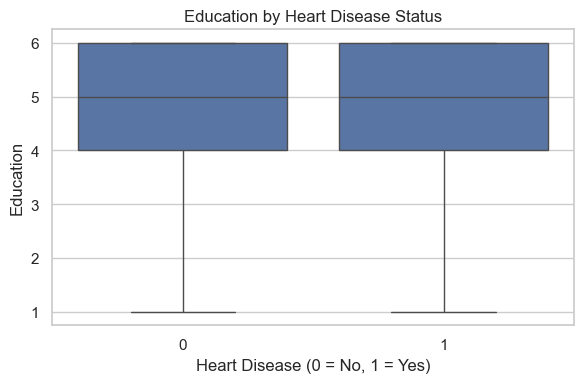

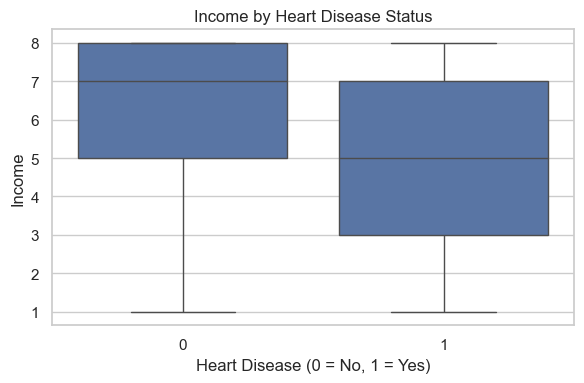

ValueError: Could not interpret value `MentalHealth` for `y`. An entry with this name does not appear in `data`.

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setup for plots
sns.set(style="whitegrid")

# Features to analyze
top_features = [
    'HighBP', 'HighChol', 'Age', 'Stroke', 'PhysActivity',
    'Diabetes', 'BMI', 'DiffWalk', 'Smoker', 'Education',
    'Income', 'AnyHealthcare', 'NoDocbcCost', 'MentalHealth'
]

# Target variable
target = 'HeartDiseaseorAttack'

# 1. Barplots for binary/categorical features
binary_features = ['HighBP', 'HighChol', 'Stroke', 'PhysActivity', 'Diabetes',
                   'DiffWalk', 'Smoker', 'AnyHealthcare', 'NoDocbcCost']

for col in binary_features:
    plt.figure(figsize=(6, 4))
    sns.barplot(x=col, y=target, data=df)
    plt.title(f"Heart Disease Rate by {col}")
    plt.ylabel("Proportion with Heart Disease")
    plt.tight_layout()
    plt.show()

# 2. Boxplots for numeric features
numeric_features = ['Age', 'BMI', 'Education', 'Income', 'MentalHealth']

for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} by Heart Disease Status")
    plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
    plt.tight_layout()
    plt.show()

# 3. Correlation Heatmap (optional)
plt.figure(figsize=(10, 8))
corr = df[top_features + [target]].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Top Influential Features")
plt.tight_layout()
plt.show()